In [91]:
# Install required packages
%pip install matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.lines as mlines

# Load the new TEE-enabled result file
file_path = "../simulators/tmp/result_100_100_5.txt"
columns = [
    "Workload", "Section", "Power", "Util", "CPU_Power", "Memory_Power", "Network_Power", 
    "Offloading_Ratio", "CPU_Frequency_1", "CPU_Frequency_0.5", "CPU_Frequency_0.25", "CPU_Frequency_0.125"
]
data = pd.read_csv(file_path, delim_whitespace=True, names=columns, skiprows=1)

# Separate data by algorithm
co_dmo_ct = data[data["Section"] == "CO-DMO-CT"]
co_dmo = data[data["Section"] == "CO-DMO"]
offloading = data[data["Section"] == "Offloading"]
dvs = data[data["Section"] == "DVS"]
baseline = data[data["Section"] == "Baseline"]

print("Data loaded successfully!")
print(f"Total records: {len(data)}")
print(f"Algorithms: {data['Section'].unique()}")
print(f"Workload range: {data['Workload'].min()} - {data['Workload'].max()}")

Data loaded successfully!
Total records: 55
Algorithms: ['CO-DMO-CT' 'CO-DMO' 'Offloading' 'DVS' 'Baseline']
Workload range: 0.2 - 1.2


/tmp/ipykernel_28889/1706977954.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, names=columns, skiprows=1)


## 1. Energy Consumption

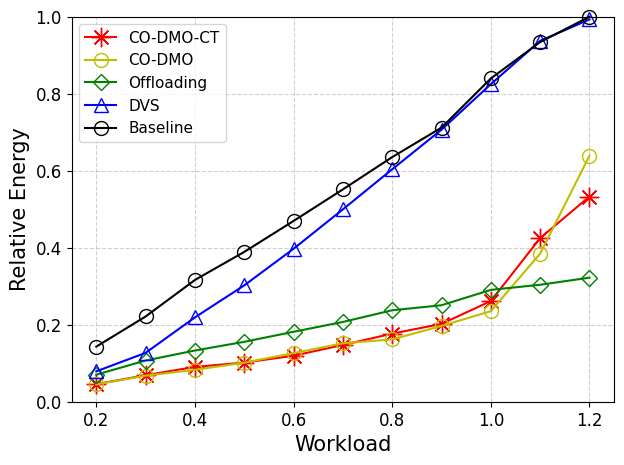

In [93]:
# 1. Energy Consumption Analysis using already loaded data
import matplotlib.pyplot as plt
import numpy as np

# Use the already loaded and parsed data from the previous cell
# Prepare energy data dictionary for 5 algorithms
energy_data = {
    "Baseline": {},
    "DVS": {},
    "Offloading": {},
    "CO-DMO": {},
    "CO-DMO-CT": {}
}

# Extract energy data from the already loaded dataframes
for _, row in baseline.iterrows():
    energy_data["Baseline"][row["Workload"]] = row["Power"]

for _, row in dvs.iterrows():
    energy_data["DVS"][row["Workload"]] = row["Power"]

for _, row in offloading.iterrows():
    energy_data["Offloading"][row["Workload"]] = row["Power"]

for _, row in co_dmo.iterrows():
    energy_data["CO-DMO"][row["Workload"]] = row["Power"]

for _, row in co_dmo_ct.iterrows():
    energy_data["CO-DMO-CT"][row["Workload"]] = row["Power"]

# Get sorted workload values
workloads = sorted(energy_data["Baseline"].keys())

# Normalize energy values to 0-1 range (Baseline reference)
max_energy = max(energy_data["Baseline"].values())
for method in energy_data:
    energy_data[method] = {w: e / max_energy for w, e in energy_data[method].items()}

# Create academic-style energy consumption plot
plt.figure(figsize=(7, 5))
plt.plot(workloads, [energy_data["CO-DMO-CT"][w] for w in workloads],
         marker=(8, 2, 0), color='r', label="CO-DMO-CT", markersize=14, clip_on=False)
plt.plot(workloads, [energy_data["CO-DMO"][w] for w in workloads],
         'yo-', label="CO-DMO", markersize=10, markerfacecolor='none', clip_on=False)
plt.plot(workloads, [energy_data["Offloading"][w] for w in workloads],
         'gD-', label="Offloading", markersize=8, markerfacecolor='none', clip_on=False)
plt.plot(workloads, [energy_data["DVS"][w] for w in workloads],
         'b^-', label="DVS", markersize=10, markerfacecolor='none', clip_on=False)
plt.plot(workloads, [energy_data["Baseline"][w] for w in workloads],
         'ko-', label="Baseline", markersize=10, markerfacecolor='none', clip_on=False)

plt.xlabel("Workload", fontsize=15)
plt.ylabel("Relative Energy", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1)  # y축 최대값을 1로 설정
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## 2. Cpufreq & Offloading

Processing method: Baseline (Baseline)


/tmp/ipykernel_28889/1657741390.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, skiprows=1, names=[


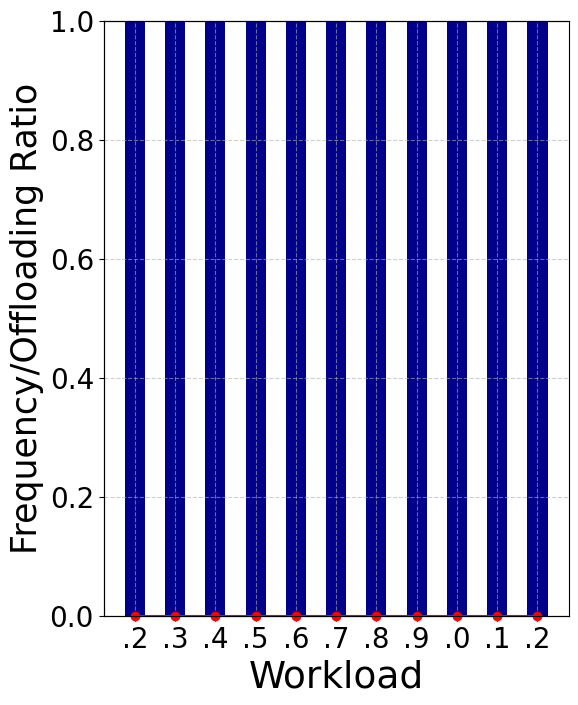

Processing method: DVS (DVS)


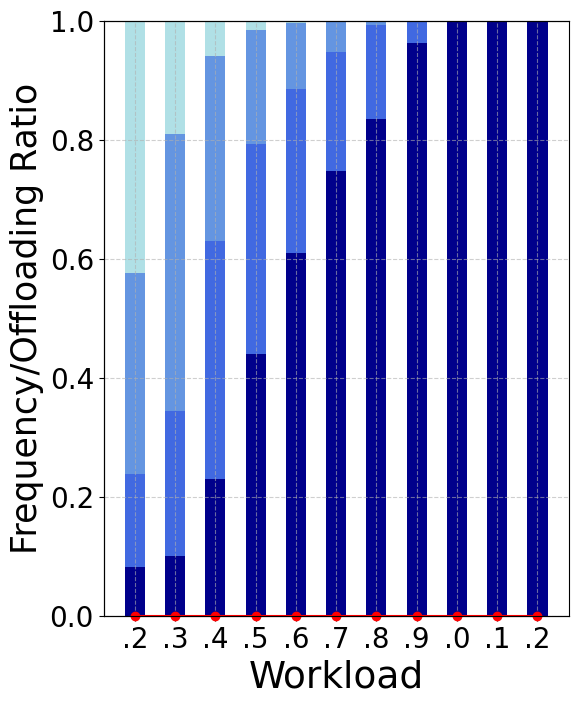

Processing method: Offloading (Offloading)


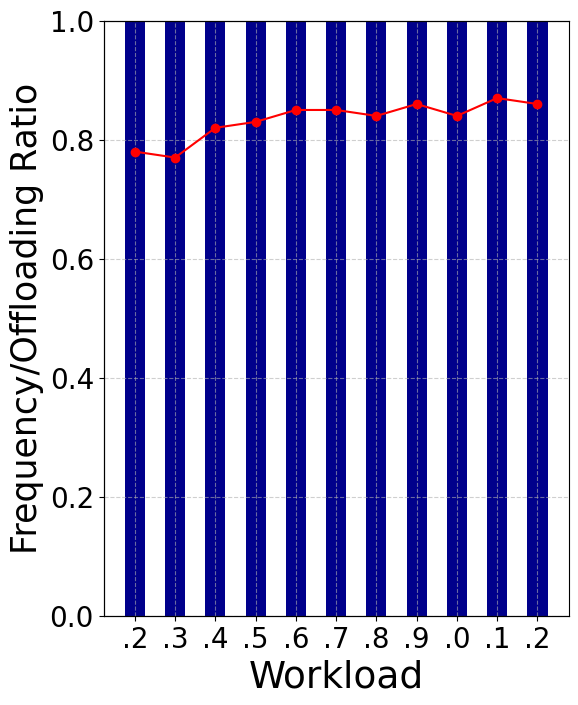

Processing method: CO-DMO (CO-DMO)


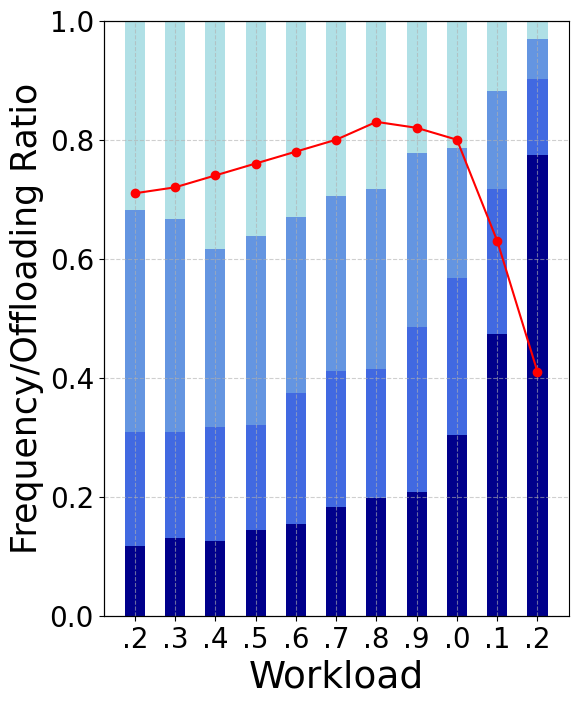

Processing method: CO-DMO-CT (CO-DMO-CT)


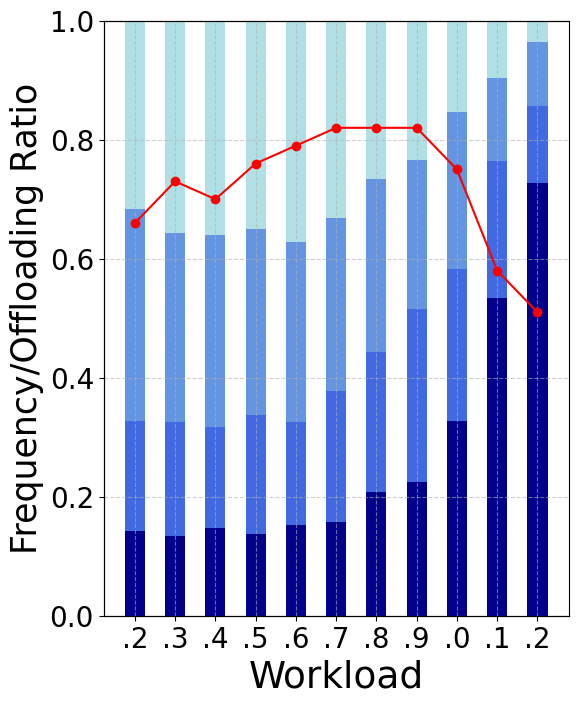

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# CSV 파일을 DataFrame으로 변환 (구분자는 쉼표)
df = pd.read_csv(file_path, delim_whitespace=True, skiprows=1, names=[
    "Workload", "Section", "Power", "Util", "CPU_Power", "Memory_Power", "Network_Power",
    "Offloading_Ratio", "CPU_Frequency_1", "CPU_Frequency_0.5", "CPU_Frequency_0.25", "CPU_Frequency_0.125"
])



# Workload 값 추출
workloads = sorted(df["Workload"].unique())

# CPU Frequency 관련 컬럼 및 색상
cpu_freq_cols = ["CPU_Frequency_1", "CPU_Frequency_0.5", "CPU_Frequency_0.25", "CPU_Frequency_0.125"]
colors = ["#00008B", "#4169E1", "#6495E1", "#B0E0E6"]

# 범례 라벨 매핑
freq_labels = {
    "CPU_Frequency_1": "1",
    "CPU_Frequency_0.5": "0.5",
    "CPU_Frequency_0.25": "0.25",
    "CPU_Frequency_0.125": "0.125"
}

# 분석 방법 매핑
method_mapping = {
    "Baseline": "Baseline",    
    "DVS": "DVS",
    "Offloading": "Offloading",
    "CO-DMO": "CO-DMO",
    "CO-DMO-CT": "CO-DMO-CT"
}

# 그래프 생성
for method_label, section_value in method_mapping.items():
    print(f"Processing method: {method_label} ({section_value})")
    df_method = df[df["Section"] == section_value].copy()
    cpu_freq_data = df_method.groupby("Workload")[cpu_freq_cols].mean().reindex(workloads, fill_value=0)
    row_sums = cpu_freq_data.sum(axis=1).replace(0, 1)
    cpu_freq_data_norm = cpu_freq_data.div(row_sums, axis=0)

    offloading_ratio = df_method.groupby("Workload")["Offloading_Ratio"].mean().reindex(workloads, fill_value=0)

    fig, ax1 = plt.subplots(figsize=(6, 8.5))
    bar_width = 0.5
    positions = np.arange(len(workloads))
    bottom = np.zeros(len(workloads))

    # 스택형 막대 그래프
    for i, freq in enumerate(cpu_freq_cols):
        ax1.bar(positions, cpu_freq_data_norm[freq], bottom=bottom, color=colors[i],
                width=bar_width, label=freq_labels.get(freq, freq))
        bottom += cpu_freq_data_norm[freq].values

    ax1.set_xlabel("Workload", fontsize=27)
    ax1.set_ylabel("Frequency/Offloading Ratio", fontsize=25)
    ax1.set_xticks(positions)

    # 0.1 -> .1 표시
    formatted_workloads = [f".{str(w).split('.')[1]}" for w in workloads]
    ax1.set_xticklabels(formatted_workloads, fontsize=20)


    
    ax1.set_ylim(0, 1)
    ax1.set_yticks(np.linspace(0, 1, 6))  # y축 눈금: 0~1까지 고정
    ax1.tick_params(axis='y', labelsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_axisbelow(False)

    # Offloading Ratio 라인 그래프
    ax2 = ax1.twinx()
    ax2.plot(positions, offloading_ratio, marker="o", markersize=6, color="red",
             linestyle="-", label="Offloading Ratio", clip_on=False)
    ax2.set_ylim(0, 1)
    ax2.set_yticks([])  # 오른쪽 y축 눈금 제거
    ax2.set_ylabel("")  
    ax2.spines["right"].set_visible(False)

    # ------------------------
    # 범례를 아래로 빼서 따로 표시 (그래프 제외)
    # ------------------------
    handles_bar, labels_bar = ax1.get_legend_handles_labels()
    handles_line, labels_line = ax2.get_legend_handles_labels()
    handles = handles_bar + [handles_line[0]]
    labels = labels_bar + [labels_line[0]]

    #fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.005),
   #            ncol=3, fontsize=16, frameon=False)

    # 그래프-범례 간 여백 확보
    plt.subplots_adjust(bottom=0.18)
    plt.show()

# 3. Util

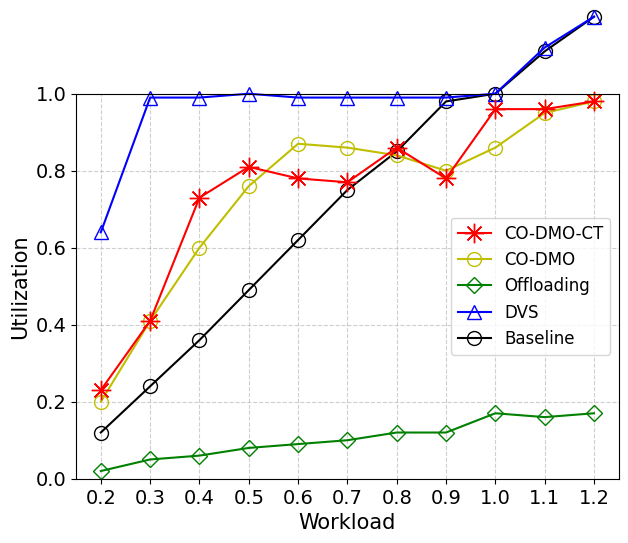

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Workload 값 추출 (예: 0.1 ~ 0.9)
workloads = sorted(df["Workload"].unique())

# 사용할 섹션 및 범례 표기 (CSV의 Section 값은 그대로 사용하되, 범례 표기를 변경)
methods = ["Baseline", "DVS", "Offloading", "CO-DMO", "CO-DMO-CT"]
legend_labels = {
    "Baseline": "Baseline",
    "DVS": "DVS",           # 범례에서는 "DVS"로 표기
    "Offloading": "Offloading",
    "CO-DMO": "CO-DMO",
    "CO-DMO-CT": "CO-DMO-CT"
}

# 에너지 그래프와 동일한 스타일 적용:
# - Baseline: 'ko-'  → marker: 'o', color: 'k', markersize: 10
# - DVFS: 'b^-'       → marker: '^', color: 'b', markersize: 10
# - Offloading: 'gD-'  → marker: 'D', color: 'g', markersize: 8
# - CO-DMO: 'yo-'     → marker: 'o', color: 'y', markersize: 10
# - CO-DMO-CT: marker=(8,2,0), color: 'r', markersize: 14
colors = {
    "Baseline": "k",
    "DVS": "b",
    "Offloading": "g",
    "CO-DMO": "y",
    "CO-DMO-CT": "r"
}
markers = {
    "Baseline": "o",
    "DVS": "^",
    "Offloading": "D",
    "CO-DMO": "o",
    "CO-DMO-CT": (8, 2, 0)
}
marker_sizes = {
    "Baseline": 10,
    "DVS": 10,
    "Offloading": 8,
    "CO-DMO": 10,
    "CO-DMO-CT": 14
}

plt.figure(figsize=(7, 5))

# 각 섹션별로 Util 값 평균을 계산하여 플롯 (에너지 그래프와 동일한 표식자, 색상, 선 스타일)
for method in methods:
    df_method = df[df["Section"] == method]
    # Workload별 평균 Util 계산 (없으면 0으로 채움)
    utilization = df_method.groupby("Workload")["Util"].mean().reindex(workloads, fill_value=0)
    x_vals = np.array(workloads)
    
    if method == "CO-DMO-CT":
        plt.plot(x_vals, utilization,
                 marker=markers[method],
                 color=colors[method],
                 label=legend_labels[method],
                 markersize=marker_sizes[method],
                 clip_on=False)
    elif method == "CO-DMO":
        plt.plot(x_vals, utilization,
                 'yo-', label=legend_labels[method],
                 markersize=marker_sizes[method],
                 markerfacecolor='none',
                 clip_on=False)
    elif method == "Offloading":
        plt.plot(x_vals, utilization,
                 'gD-', label=legend_labels[method],
                 markersize=marker_sizes[method],
                 markerfacecolor='none',
                 clip_on=False)
    elif method == "DVS":
        plt.plot(x_vals, utilization,
                 'b^-', label=legend_labels[method],
                 markersize=marker_sizes[method],
                 markerfacecolor='none',
                 clip_on=False)
    elif method == "Baseline":
        plt.plot(x_vals, utilization,
                 'ko-', label=legend_labels[method],
                 markersize=marker_sizes[method],
                 markerfacecolor='none',
                 clip_on=False)

plt.xlabel("Workload", fontsize=15)
plt.ylabel("Utilization", fontsize=15)
plt.xticks(workloads, fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# 기존 자동 legend → handles 추출 후 역순 정렬
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], fontsize=12)

plt.show()



## 4. Realistic - Relative Energy

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV 파일 불러오기
csv_path = "experiment_results/results_summary.csv"
data = pd.read_csv(csv_path)

# 각 네트워크 속도별로 baseline의 Total_Power를 기준으로 정규화
baseline_powers = data[data['Algorithm'] == 'baseline'].set_index('Network_Speed')['Total_Power']
data['Normalized_Power'] = data.apply(lambda row: row['Total_Power'] / baseline_powers[row['Network_Speed']], axis=1)

# 정규화된 값으로 에너지 비율 계산
data["CPU%"] = data["CPU_Power"] / data["Total_Power"]
data["Memory%"] = data["Memory_Power"] / data["Total_Power"]
data["Network%"] = data["Network_Power"] / data["Total_Power"]

# 알고리즘 순서 정리
alg_order = ["baseline", "dvs", "offloading", "co-dmo", "co-dmo-ct"]

# 평균 에너지 비율 계산
avg_energy = data.groupby("Algorithm")[["CPU%", "Memory%", "Network%"]].mean().loc[alg_order]

# 시각화
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# 상단: 알고리즘별 평균 에너지 구성 (stacked bar)
avg_energy.plot(kind="bar", stacked=True, ax=axs[0], color=["#4c78a8", "#72b7b2", "#f58518"])
axs[0].set_title("Relative Energy Composition per Algorithm")
axs[0].set_ylabel("Relative Energy Ratio")
axs[0].legend(loc="upper right")
axs[0].set_ylim(0, 1.0)  # y축 최대값을 1.0으로 설정
axs[0].margins(y=0.2)    # y축 여백을 20% 추가 (1.2까지 보이도록)

# 하단: 네트워크 속도별 정규화된 에너지 변화 (line plot)
line_data = data[data["Algorithm"].isin(["baseline", "dvs", "offloading", "co-dmo-ct"])]
sns.lineplot(
    data=line_data,
    x="Network_Speed",
    y="Normalized_Power",
    hue="Algorithm",
    marker="o",
    hue_order=["co-dmo-ct", "offloading", "dvs", "baseline"],
    ax=axs[1]
)
axs[1].set_title("Normalized Energy vs. Network Speed")
axs[1].set_ylabel("Normalized Energy (Baseline=1.0)")
axs[1].set_xlabel("Network Speed (Mbps)")
axs[1].set_ylim(0, 1.0)  # y축 최대값을 1.0으로 설정
axs[1].margins(y=0.2)    # y축 여백을 20% 추가 (1.2까지 보이도록)
axs[1].legend(title="Algorithm")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'experiment_results/results_summary.csv'